In [ ]:
# ============================================================
# PROJECT 2: Sampling Plan Design & Automated Statistical
# Reporting Pipeline for a Social Welfare Beneficiary Survey
# ============================================================
#
# CONTEXT: Simulates the kind of study a Ministry/UN program might
# commission to assess a welfare scheme - "how aware are eligible
# beneficiaries, and what predicts whether they actually receive it?"
#
# Workflow: design sampling plan -> simulate dataset -> clean -> analyze
# -> auto-generate charts and a written report.
#
# METHODOLOGY NOTE: beneficiary-level survey microdata is rarely public
# (privacy-restricted), so Part B uses a SIMULATED dataset with realistic,
# documented assumptions. Part A (the sampling calculator) is fully real,
# reusable code - plug in actual population figures for any real study.

In [ ]:
!pip install statsmodels -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(7)


base_n_simple_random               : 384
n_after_fpc                        : 384
n_after_design_effect              : 575
final_n_after_nonresponse_adj      : 640

Total sample required: 640
Proportional allocation across states:
  State A: 154
  State B: 128
  State C: 115
  State D: 141
  State E: 102
  Check — sum: 640


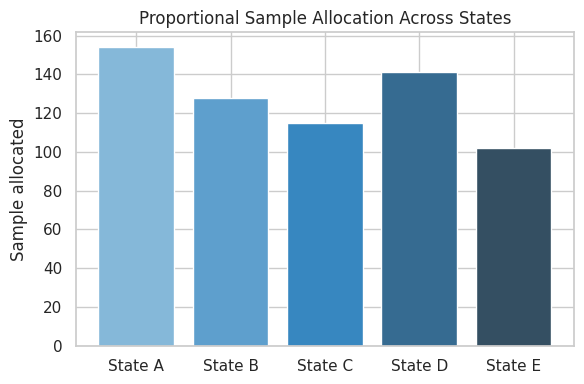

In [ ]:
# ---------------------------------------------------------
# PART A: Sample Size & Stratified Sampling Plan
# Reusable function with finite population correction, design effect,
# and non-response adjustment.
# ---------------------------------------------------------
def sample_size_proportion(population_size, expected_prop=0.5, confidence=0.95,
                            margin_error=0.05, design_effect=1.5, non_response_rate=0.1):
    """
    Calculate required sample size to estimate a population proportion.

    population_size : int    Total eligible population (e.g. registered beneficiaries)
    expected_prop    : float Best-guess proportion being estimated (0.5 = most conservative)
    confidence       : float Confidence level (e.g. 0.95 for 95%)
    margin_error     : float Desired margin of error (e.g. 0.05 for +/-5 points)
    design_effect    : float Inflation factor for clustering/multi-stage sampling
    non_response_rate: float Expected proportion of sampled units that won't respond
    """
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    n0 = (z ** 2 * expected_prop * (1 - expected_prop)) / (margin_error ** 2)
    n_fpc = n0 / (1 + (n0 - 1) / population_size) if population_size else n0
    n_deff = n_fpc * design_effect
    n_final = n_deff / (1 - non_response_rate)
    return {
        "base_n_simple_random": round(n0),
        "n_after_fpc": round(n_fpc),
        "n_after_design_effect": round(n_deff),
        "final_n_after_nonresponse_adj": int(np.ceil(n_final)),
    }


def allocate_stratified_sample(total_n, strata_sizes: dict):
    """Proportional allocation of total_n across strata, based on strata population sizes."""
    total_pop = sum(strata_sizes.values())
    allocation = {k: int(round(total_n * v / total_pop)) for k, v in strata_sizes.items()}
    return allocation

# Worked example: assess scheme awareness/uptake among ~2,50,000 eligible
# beneficiaries across 5 states
sample_plan = sample_size_proportion(
    population_size=250_000,
    expected_prop=0.5,       # most conservative assumption when true rate is unknown
    confidence=0.95,
    margin_error=0.05,       # +/- 5 percentage points
    design_effect=1.5,       # accounts for state/district-level clustering
    non_response_rate=0.10,  # 10% expected non-response, typical for household surveys
)
for k, v in sample_plan.items():
    print(f"{k:<35}: {v}")

state_population = {
    "State A": 60_000, "State B": 50_000, "State C": 45_000,
    "State D": 55_000, "State E": 40_000,
}

final_n = sample_plan["final_n_after_nonresponse_adj"]
allocation = allocate_stratified_sample(final_n, state_population)

print(f"\nTotal sample required: {final_n}")
print("Proportional allocation across states:")
for state, n in allocation.items():
    print(f"  {state}: {n}")
print(f"  Check — sum: {sum(allocation.values())}")

plt.figure(figsize=(6, 4))
plt.bar(allocation.keys(), allocation.values(), color=sns.color_palette("Blues_d", len(allocation)))
plt.ylabel("Sample allocated")
plt.title("Proportional Sample Allocation Across States")
plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------
# PART B: Simulating a Beneficiary Survey Dataset (~2000 responses)
# Awareness varies by category; benefit receipt depends on awareness;
# satisfaction depends on benefit receipt; ~3% income deliberately missing.
# ---------------------------------------------------------
n = 2000
states = list(state_population.keys())
state_probs = np.array(list(state_population.values())) / sum(state_population.values())

df = pd.DataFrame({
    "state": np.random.choice(states, n, p=state_probs),
    "category": np.random.choice(["SC", "ST", "OBC", "General"], n, p=[0.25, 0.12, 0.43, 0.20]),
    "gender": np.random.choice(["Male", "Female"], n, p=[0.52, 0.48]),
    "age": np.random.randint(18, 65, n),
})

base_awareness_rate = {"SC": 0.55, "ST": 0.45, "OBC": 0.60, "General": 0.65}
df["scheme_awareness"] = np.random.binomial(1, df["category"].map(base_awareness_rate))

p_benefit = np.where(df["scheme_awareness"] == 1, 0.70, 0.15)
df["benefit_received"] = np.random.binomial(1, p_benefit)

sat_mean = np.where(df["benefit_received"] == 1, 4.0, 2.5)
df["satisfaction_score"] = np.clip(np.round(np.random.normal(sat_mean, 0.8)), 1, 5).astype(int)

df["monthly_income"] = np.round(np.random.gamma(shape=4, scale=2500, size=n))

# Inject ~3% missing income (simulating real-world non-response on a sensitive question)
missing_idx = np.random.choice(n, size=int(0.03 * n), replace=False)
df.loc[missing_idx, "monthly_income"] = np.nan

df.head()

,state,category,gender,age,scheme_awareness,benefit_received,satisfaction_score,monthly_income
0,State A,OBC,Female,57,0,1,3,6363.0
1,State D,OBC,Female,52,0,1,3,3517.0
2,State B,OBC,Female,56,1,1,4,14049.0
3,State D,OBC,Female,54,1,1,4,1995.0
4,State E,OBC,Female,29,1,1,5,9627.0


In [ ]:
# ---------------------------------------------------------
# PART C: Data Cleaning Pipeline
# Reports missing values, imputes by category-level median, flags
# (doesn't drop) income outliers via IQR.
# ---------------------------------------------------------
def clean_survey_data(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    missing_report = data.isna().sum()
    missing_report = missing_report[missing_report > 0]
    if len(missing_report):
        print("Missing values found:")
        print(missing_report)

    # Impute missing income with the category-level median (preserves
    # subgroup patterns better than a single global median)
    data["monthly_income"] = data.groupby("category")["monthly_income"].transform(
        lambda s: s.fillna(s.median())
    )

    # Flag (not drop) income outliers using IQR
    q1, q3 = data["monthly_income"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    data["income_outlier_flag"] = ~data["monthly_income"].between(lower, upper)

    return data

df_clean = clean_survey_data(df)
print(f"\nOutliers flagged: {df_clean['income_outlier_flag'].sum()} of {len(df_clean)} records")
df_clean.head()


Missing values found:
monthly_income    60
dtype: int64

Outliers flagged: 34 of 2000 records


,state,category,gender,age,scheme_awareness,benefit_received,satisfaction_score,monthly_income,income_outlier_flag
0,State A,OBC,Female,57,0,1,3,6363.0,False
1,State D,OBC,Female,52,0,1,3,3517.0,False
2,State B,OBC,Female,56,1,1,4,14049.0,False
3,State D,OBC,Female,54,1,1,4,1995.0,False
4,State E,OBC,Female,29,1,1,5,9627.0,False


In [ ]:
# ---------------------------------------------------------
# PART D: Automated Statistical Analysis
# Descriptive cross-tabs, chi-square test, logistic regression
# ---------------------------------------------------------
print("Scheme awareness rate by social category:")
print((df_clean.groupby("category")["scheme_awareness"].mean() * 100).round(1).astype(str) + "%")

print("\nBenefit receipt rate by social category:")
print((df_clean.groupby("category")["benefit_received"].mean() * 100).round(1).astype(str) + "%")

print("\nAverage satisfaction score by benefit receipt status:")
print(df_clean.groupby("benefit_received")["satisfaction_score"].mean().round(2))

# Chi-square test: is benefit receipt independent of social category?
contingency = pd.crosstab(df_clean["category"], df_clean["benefit_received"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square test (category vs. benefit received): chi2 = {chi2:.2f}, df = {dof}, p = {p_value:.4f}")
print("--> Statistically significant association" if p_value < 0.05 else "--> No significant association")

import statsmodels.api as sm

# Logistic regression: what predicts whether a beneficiary actually
# received the benefit?
X = pd.get_dummies(df_clean[["category", "gender"]], drop_first=True).astype(float)
X["scheme_awareness"] = df_clean["scheme_awareness"].astype(float)
X["age"] = df_clean["age"].astype(float)
X["monthly_income_k"] = df_clean["monthly_income"] / 1000  # rescaled for interpretability
X = sm.add_constant(X)
y = df_clean["benefit_received"].astype(float)

logit_model = sm.Logit(y, X).fit(disp=0)
print(logit_model.summary())

Scheme awareness rate by social category:
category
General    65.4%
OBC        61.0%
SC         57.5%
ST         45.7%
Name: scheme_awareness, dtype: object

Benefit receipt rate by social category:
category
General    53.9%
OBC        50.3%
SC         47.1%
ST         36.6%
Name: benefit_received, dtype: object

Average satisfaction score by benefit receipt status:
benefit_received
0    2.48
1    3.95
Name: satisfaction_score, dtype: float64
Chi-square test (category vs. benefit received): chi2 = 20.36, df = 3, p = 0.0001
--> Statistically significant association
                           Logit Regression Results                           
Dep. Variable:       benefit_received   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1992
Method:                           MLE   Df Model:                            7
Date:                Sat, 20 Jun 2026   Pseudo R-squ.:                  0.2251
Time:                        15:30

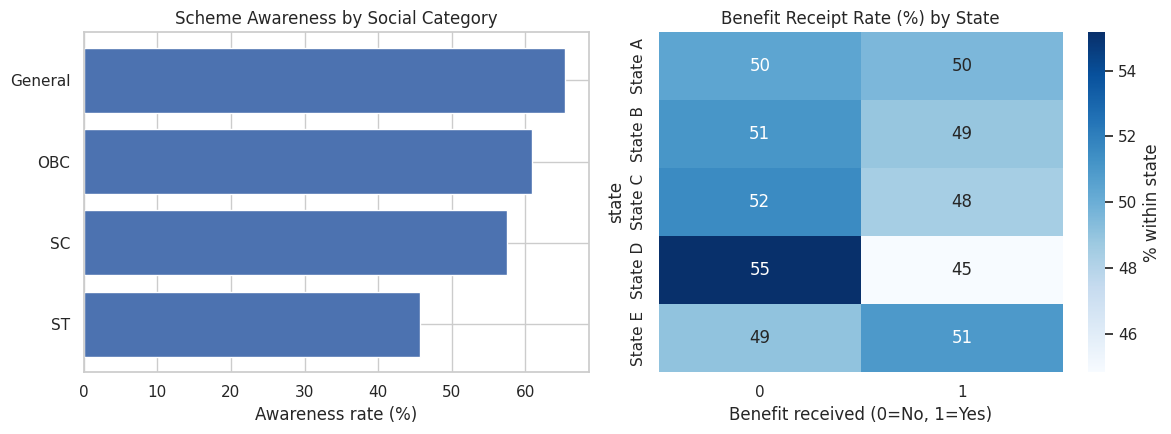

In [ ]:
# ---------------------------------------------------------
# PART E: Automated Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

awareness_by_cat = df_clean.groupby("category")["scheme_awareness"].mean().sort_values()
axes[0].barh(awareness_by_cat.index, awareness_by_cat.values * 100, color="#4C72B0")
axes[0].set_xlabel("Awareness rate (%)")
axes[0].set_title("Scheme Awareness by Social Category")

sns.heatmap(pd.crosstab(df_clean["state"], df_clean["benefit_received"], normalize="index") * 100,
            annot=True, fmt=".0f", cmap="Blues", ax=axes[1], cbar_kws={"label": "% within state"})
axes[1].set_title("Benefit Receipt Rate (%) by State")
axes[1].set_xlabel("Benefit received (0=No, 1=Yes)")

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------------------------------
# PART F: Auto-Generated Technical Report
# ---------------------------------------------------------
def generate_report(df, contingency_result, logit_result, allocation):
    lines = []
    lines.append("WELFARE SCHEME BENEFICIARY SURVEY — ANALYSIS SUMMARY (simulated data)")
    lines.append("=" * 65)
    lines.append(f"\nSample: {len(df)} respondents across {df['state'].nunique()} states "
                 f"and {df['category'].nunique()} social categories")
    lines.append(f"Planned sample (Part A): {sum(allocation.values())} "
                 f"(allocated as {allocation})")

    lines.append("\n--- Awareness & Benefit Receipt ---")
    for cat in df["category"].unique():
        sub = df[df["category"] == cat]
        lines.append(f"  {cat}: {sub['scheme_awareness'].mean()*100:.1f}% aware, "
                     f"{sub['benefit_received'].mean()*100:.1f}% received benefit")

    chi2, p_val, dof, _ = contingency_result
    lines.append(f"\n--- Statistical Tests ---")
    lines.append(f"  Category vs. benefit receipt: chi2={chi2:.2f}, p={p_val:.4f} "
                 f"({'significant' if p_val < 0.05 else 'not significant'} at alpha=0.05)")

    lines.append(f"\n  Logistic regression (predicting benefit receipt):")
    lines.append(f"    Pseudo R-squared: {logit_result.prsquared:.3f}")
    sig_predictors = logit_result.pvalues[logit_result.pvalues < 0.05].index.tolist()
    lines.append(f"    Statistically significant predictors (p<0.05): {sig_predictors}")

    lines.append("\n--- Conclusion ---")
    lines.append("Scheme awareness is the strongest predictor of whether eligible beneficiaries")
    lines.append("actually receive support, with meaningful variation across social categories and")
    lines.append("states. This suggests outreach/awareness campaigns — not just scheme design — are")
    lines.append("a key lever for improving benefit uptake.")

    return "\n".join(lines)

chi2_res = stats.chi2_contingency(pd.crosstab(df_clean["category"], df_clean["benefit_received"]))
report_text = generate_report(df_clean, chi2_res, logit_model, allocation)
print(report_text)

with open("welfare_survey_analysis_report.txt", "w") as f:
    f.write(report_text)
print("\n[Saved to welfare_survey_analysis_report.txt]")


WELFARE SCHEME BENEFICIARY SURVEY — ANALYSIS SUMMARY (simulated data)

Sample: 2000 respondents across 5 states and 4 social categories
Planned sample (Part A): 640 (allocated as {'State A': 154, 'State B': 128, 'State C': 115, 'State D': 141, 'State E': 102})

--- Awareness & Benefit Receipt ---
  OBC: 61.0% aware, 50.3% received benefit
  General: 65.4% aware, 53.9% received benefit
  SC: 57.5% aware, 47.1% received benefit
  ST: 45.7% aware, 36.6% received benefit

--- Statistical Tests ---
  Category vs. benefit receipt: chi2=20.36, p=0.0001 (significant at alpha=0.05)

  Logistic regression (predicting benefit receipt):
    Pseudo R-squared: 0.225
    Statistically significant predictors (p<0.05): ['const', 'scheme_awareness']

--- Conclusion ---
Scheme awareness is the strongest predictor of whether eligible beneficiaries
actually receive support, with meaningful variation across social categories and
states. This suggests outreach/awareness campaigns — not just scheme design — a